## Writing a video using OpenCV
While building applications, it becomes important to save demo videos of your work as well as many applications themselves might require saving a video clip. For example, in a surveiallance application, you might have to save a video clip as soon as you see something unusual happening.

In this notebook, we will describe how to save a video in **avi** and **mp4** formats using OpenCV.

In [1]:
# import the library
import os
import cv2
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import YouTubeVideo, display, HTML
from base64 import b64encode

%matplotlib inline

## Read Video from Source

In [ ]:
source = 'race_car.mp4'  # source = 0 for webcam

cap = cv2.VideoCapture(source)

In [12]:
if not cap.isOpened():
    print("Error opening video stream or file")

### <font color="green">Read and display one frame </font>

In [13]:
ret, frame = cap.read()

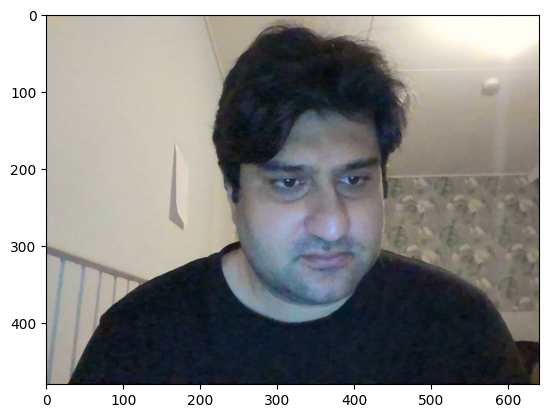

In [14]:
plt.imshow(frame[..., ::-1])

### <font color="green">Display the video file </font>

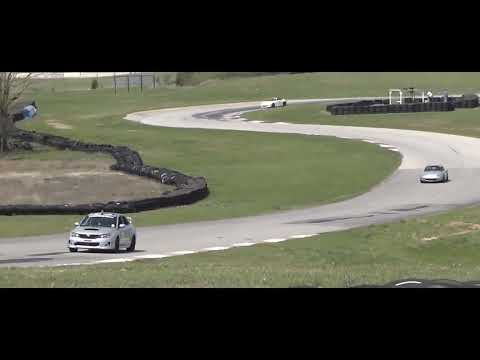

In [6]:
video = YouTubeVideo("RwxVEjv78LQ", width=700, height=438)
display(video)

## Write Video using OpenCV
For writing the video, you need to create a videowriter object with the right parameters.

### <font color="green">Function Syntax</font>

```python
VideoWriter object = cv.VideoWriter(filename, fourcc, fps, frameSize )
```
where,
**Parameters**

1. `filename`: Name of the output video file.

2. `fourcc`: 4-character code of codec used to compress the frames. For example, `VideoWriter::fourcc('P','I','M','1')` is a MPEG-1 codec, VideoWriter::fourcc('M','J','P','G') is a motion-jpeg codec etc. List of codes can be obtained at Video Codecs by FOURCC page. FFMPEG backend with MP4 container natively uses other values as fourcc code: see ObjectType, so you may receive a warning message from OpenCV about fourcc code conversion.

3. `fps`: Framerate of the created video stream.

4. `frameSize`: Size of the video frames.

In [7]:
# Default resolutions of the frame are obtained.
# Convert the resolutions from float to integer.
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

# Define the codec and create VideoWriter object.
out_avi = cv2.VideoWriter("race_car_out.avi", cv2.VideoWriter_fourcc("M", "J", "P", "G"), 10, (frame_width, frame_height))

out_mp4 = cv2.VideoWriter("race_car_out.mp4", cv2.VideoWriter_fourcc(*"XVID"), 10, (frame_width, frame_height))

### <font color="green">Read frames and write to file</font>
We will read the frames from the race-car video and write the same to the two objects we created in the previous step. We should release the objects after the task is complete.

In [8]:
# Read until video is completed
while cap.isOpened():
    # Capture frame-by-frame
    ret, frame = cap.read()

    if ret:
        # Write the frame to the output files
        out_avi.write(frame)
        out_mp4.write(frame)

    # Break the loop
    else:
        break

In [9]:
# When everything done, release the VideoCapture and VideoWriter objects
cap.release()
out_avi.release()
out_mp4.release()

To display video on Google Colab, we will install and use the `ffmpeg` package. Using `ffmpeg` we will change the encoding of the `.mp4` file from XVID to H264

HTML 5 can properly render videos with H264 encoding and OpenCV doesn't have that encoding yet. That's why we need to change their encodings such that they can be rendered.

In [10]:
# Installing ffmpeg

!apt-get -qq install ffmpeg

'apt-get' is not recognized as an internal or external command,
operable program or batch file.


Currently, HTML5 only suports renedering of MP4 files, so we'll only change the encoding of the `race_car_out.mp4` file.

In [11]:
# Change video encoding of mp4 file from XVID to h264
!ffmpeg -y -i "/content/race_car_out.mp4" -c:v libx264 "race_car_out_x264.mp4"  -hide_banner -loglevel error

'ffmpeg' is not recognized as an internal or external command,
operable program or batch file.


Render MP4 Video

In [12]:
mp4 = open("/content/race_car_out_x264.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""<video width=700 controls><source src="{data_url}" type="video/mp4"></video>""")

FileNotFoundError: [Errno 2] No such file or directory: '/content/race_car_out_x264.mp4'

The video rendered in the above cell should be the same as the following.

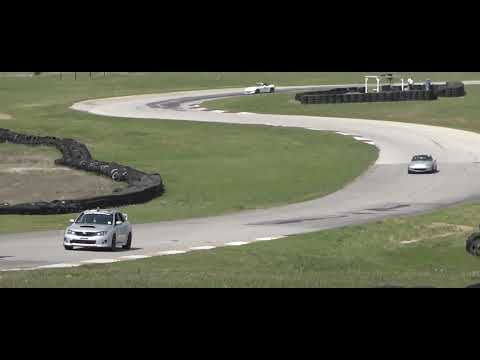

In [ ]:
video = YouTubeVideo("2Gju7YLfkP0", width=700, height=438)
display(video)